In [7]:
from pathlib import Path
import sys
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys

sys.path.insert(0, '..')
sys.path.insert(0, '../src')

from src.config import DR_GRADES
from src.preprocessing import ben_graham_preprocess
from src.dataset import get_train_val_split
from src.model import create_model, create_baseline_model

PROJECT_ROOT = 'C:/Projects/dr-detect'
SRC_DIR = PROJECT_ROOT + "/src"

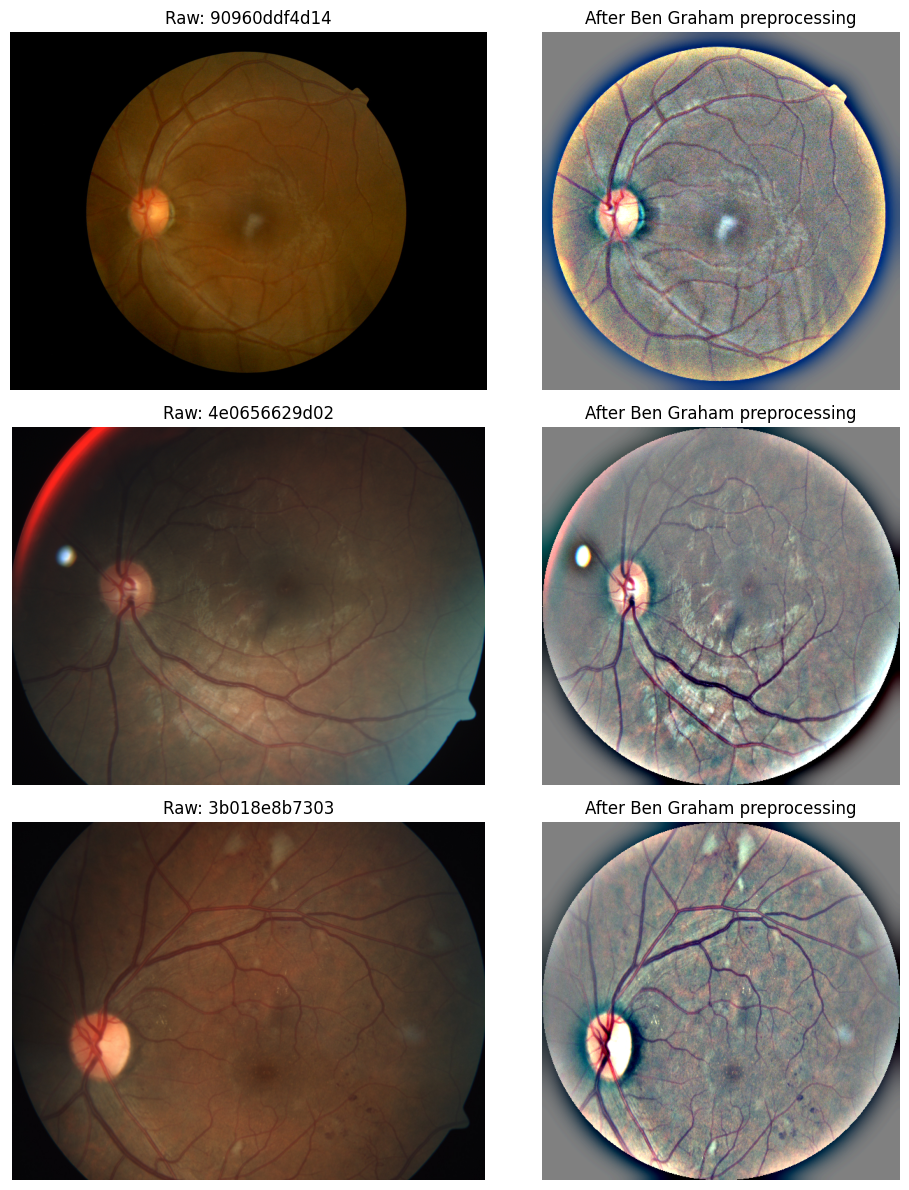

In [9]:
IMG_DIR = PROJECT_ROOT + "/aptos/aptos2019-blindness-detection/train_images"
aptos_df = pd.read_csv(PROJECT_ROOT + "/aptos/aptos2019-blindness-detection/train.csv")
sample_ids = aptos_df["id_code"].sample(3, random_state=42).tolist()

fig, axes = plt.subplots(len(sample_ids), 2, figsize=(10, 4 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = np.array([axes])

for i, image_id in enumerate(sample_ids):
    img_path = IMG_DIR + f"/{image_id}.png"
    bgr = cv2.imread(img_path)

    pre = ben_graham_preprocess(bgr, target_size=512)

    rgb_raw = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_pre = cv2.cvtColor(pre, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(rgb_raw)
    axes[i, 0].set_title(f"Raw: {image_id}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(rgb_pre)
    axes[i, 1].set_title("After Ben Graham preprocessing")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 5) Train/validation split 
`src/dataset.py`.

In [23]:
aptos_df = pd.read_csv("../aptos/aptos2019-blindness-detection/train.csv")
train_df, val_df = get_train_val_split(aptos_df, val_fold=0)

print(f"Train fold size: {len(train_df)}")
print(f"Val fold size:   {len(val_df)}")
display(train_df.head())

Train fold size: 2929
Val fold size:   733


,id_code,diagnosis,fold
0,000c1434d8d7,2,2
1,0024cdab0c1e,1,1
2,005b95c28852,0,4
3,00a8624548a9,2,3
4,00b74780d31d,2,1


## 6) Model components (baseline vs CBAM)
- Baseline: ResNet50 ImageNet weights
- CBAM: ResNet50 + CBAM attention modules (channel + spatial)

In [30]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

baseline = create_baseline_model(pretrained=False)
cbam = create_model(pretrained=False)

print(f"Baseline parameters: {count_params(baseline):,}")

print("Baseline head:")
print(baseline.layer1)

print(baseline.mc_dropout)
print(baseline.fc)

Baseline parameters: 23,518,277
Baseline head:
Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

In [17]:
print(f"CBAM parameters:{count_params(cbam):,}")
print("CBAM blocks:")
print(cbam.cbam1)
print(cbam.cbam2)
print(cbam.cbam3)
print(cbam.cbam4)

CBAM parameters:24,214,989
CBAM blocks:
CBAM(
  (channel_att): ChannelAttention(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=16, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=16, out_features=256, bias=False)
    )
  )
  (spatial_att): SpatialAttention(
    (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
  )
)
CBAM(
  (channel_att): ChannelAttention(
    (mlp): Sequential(
      (0): Linear(in_features=512, out_features=32, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=32, out_features=512, bias=False)
    )
  )
  (spatial_att): SpatialAttention(
    (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
  )
)
CBAM(
  (channel_att): ChannelAttention(
    (mlp): Sequential(
      (0): Linear(in_features=1024, out_features=64, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=1024, bias=False)
    )
  )
  (s

## 7) Results

In [ ]:
def latest_match(pattern: str):
    files = sorted(glob.glob(pattern), key=lambda p: Path(p).stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError(f"No files matched: {pattern}")
    return Path(files[0])

baseline_metrics_path = latest_match(str(phase3_dir / "outputs" / "results" / "baseline_messidor2_*_20T_1744img_metrics.json"))
cbam_metrics_path = latest_match(str(phase3_dir / "outputs" / "results" / "cbam_messidor2_*_20T_1744img_metrics.json"))

print("Baseline metrics file:", baseline_metrics_path.relative_to(PROJECT_ROOT))
print("CBAM metrics file:", cbam_metrics_path.relative_to(PROJECT_ROOT))

with open(baseline_metrics_path, "r", encoding="utf-8") as f:
    baseline_metrics = json.load(f)
with open(cbam_metrics_path, "r", encoding="utf-8") as f:
    cbam_metrics = json.load(f)

print("Baseline metrics:")
print(json.dumps(baseline_metrics, indent=2)[:4000])

Baseline metrics file: phase3-results\outputs\results\baseline_messidor2_20260331_151732_20T_1744img_metrics.json
CBAM metrics file: phase3-results\outputs\results\cbam_messidor2_20260331_151850_20T_1744img_metrics.json
Baseline metrics:
{
  "run_info": {
    "model": "baseline",
    "checkpoint": "baseline_resnet50_fold0_best.pth",
    "checkpoint_epoch": 13,
    "checkpoint_best_kappa": 0.9088493152124479,
    "dataset": "messidor2",
    "n_images": 1744,
    "mc_passes": 20,
    "batch_size": 16,
    "image_size": 512,
    "device": "cuda",
    "timestamp": "2026-03-31T15:18:25.207631"
  },
  "accuracy": 0.6399082568807339,
  "quadratic_kappa": 0.599972462479335,
  "binary_referable_auc": 0.8911246788708496,
  "binary_referable_sens": 0.44638949671772427,
  "binary_referable_spec": 0.9766899766899767,
  "classification_report": {
    "No DR": {
      "precision": 0.7108695652173913,
      "recall": 0.9646017699115044,
      "f1-score": 0.818523153942428,
      "support": 1017.0
    

In [41]:
print("CBAM metrics JSON:")
print(json.dumps(cbam_metrics, indent=2)[:4000])

CBAM metrics JSON:
{
  "run_info": {
    "model": "cbam",
    "checkpoint": "cbam_resnet50_20260331_114901_fold0_best.pth",
    "checkpoint_epoch": 16,
    "checkpoint_best_kappa": 0.889575848472602,
    "dataset": "messidor2",
    "n_images": 1744,
    "mc_passes": 20,
    "batch_size": 16,
    "image_size": 512,
    "device": "cuda",
    "timestamp": "2026-03-31T15:19:44.435039"
  },
  "accuracy": 0.6095183486238532,
  "quadratic_kappa": 0.5784200249062024,
  "binary_referable_auc": 0.8777677464767181,
  "binary_referable_sens": 0.37199124726477023,
  "binary_referable_spec": 0.9735819735819736,
  "classification_report": {
    "No DR": {
      "precision": 0.7085755813953488,
      "recall": 0.9587020648967551,
      "f1-score": 0.8148767237776849,
      "support": 1017.0
    },
    "Mild": {
      "precision": 0.08536585365853659,
      "recall": 0.05185185185185185,
      "f1-score": 0.06451612903225806,
      "support": 270.0
    },
    "Moderate": {
      "precision": 0.45205479

## 9) bảng so sánh

In [42]:
rows = [
    {
        "model": "baseline",
        "accuracy": baseline_metrics["accuracy"],
        "qwk": baseline_metrics["quadratic_kappa"],
        "referable_auc": baseline_metrics["binary_referable_auc"],
        "referable_sens": baseline_metrics["binary_referable_sens"],
        "referable_spec": baseline_metrics["binary_referable_spec"],
        "ece": baseline_metrics.get("ece", np.nan),
        "brier_score": baseline_metrics.get("brier_score", np.nan),
    },
    {
        "model": "cbam",
        "accuracy": cbam_metrics["accuracy"],
        "qwk": cbam_metrics["quadratic_kappa"],
        "referable_auc": cbam_metrics["binary_referable_auc"],
        "referable_sens": cbam_metrics["binary_referable_sens"],
        "referable_spec": cbam_metrics["binary_referable_spec"],
        "ece": cbam_metrics.get("ece", np.nan),
        "brier_score": cbam_metrics.get("brier_score", np.nan),
    },
]

compare_df = pd.DataFrame(rows)
display(compare_df)

,model,accuracy,qwk,referable_auc,referable_sens,referable_spec,ece,brier_score
0,baseline,0.639908,0.599972,0.891125,0.446389,0.976690,0.133822,0.508390
1,cbam,0.609518,0.578420,0.877768,0.371991,0.973582,0.120073,0.517023


### Referral-curve 

In [44]:
baseline_ref_path = latest_match(str(phase3_dir / "outputs" / "results" / "baseline_messidor2_*_20T_1744img_referral_curve.csv"))
cbam_ref_path = latest_match(str(phase3_dir / "outputs" / "results" / "cbam_messidor2_*_20T_1744img_referral_curve.csv"))

baseline_ref = pd.read_csv(baseline_ref_path)
cbam_ref = pd.read_csv(cbam_ref_path)

display(baseline_ref)
display(cbam_ref)

,quantile,entropy_threshold,coverage,accuracy,referable_sensitivity,referable_specificity
0,0.50,0.584309,0.500000,0.799312,0.339286,0.988971
1,0.60,0.697731,0.599771,0.780115,0.370787,0.990596
2,0.70,0.830898,0.700115,0.743653,0.381579,0.990645
3,0.80,0.984756,0.799885,0.706810,0.455696,0.988774
4,0.90,1.151290,0.899656,0.671765,0.442136,0.984578
5,0.95,1.259699,0.949541,0.652174,0.431122,0.980222


,quantile,entropy_threshold,coverage,accuracy,referable_sensitivity,referable_specificity
0,0.50,0.656055,0.500000,0.782110,0.018868,1.000000
1,0.60,0.824261,0.599771,0.769598,0.105263,0.998969
2,0.70,1.021704,0.700115,0.740377,0.250000,0.994511
3,0.80,1.201282,0.799885,0.694624,0.271028,0.991533
4,0.90,1.354904,0.899656,0.649458,0.350877,0.989405
5,0.95,1.463938,0.949541,0.631039,0.364532,0.986400


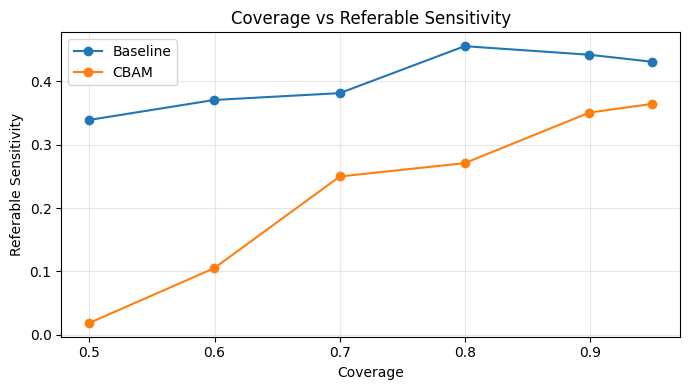

In [46]:

plt.figure(figsize=(7, 4))
plt.plot(baseline_ref["coverage"], baseline_ref["referable_sensitivity"], marker="o", label="Baseline")
plt.plot(cbam_ref["coverage"], cbam_ref["referable_sensitivity"], marker="o", label="CBAM")
plt.xlabel("Coverage")
plt.ylabel("Referable Sensitivity")
plt.title("Coverage vs Referable Sensitivity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reliability

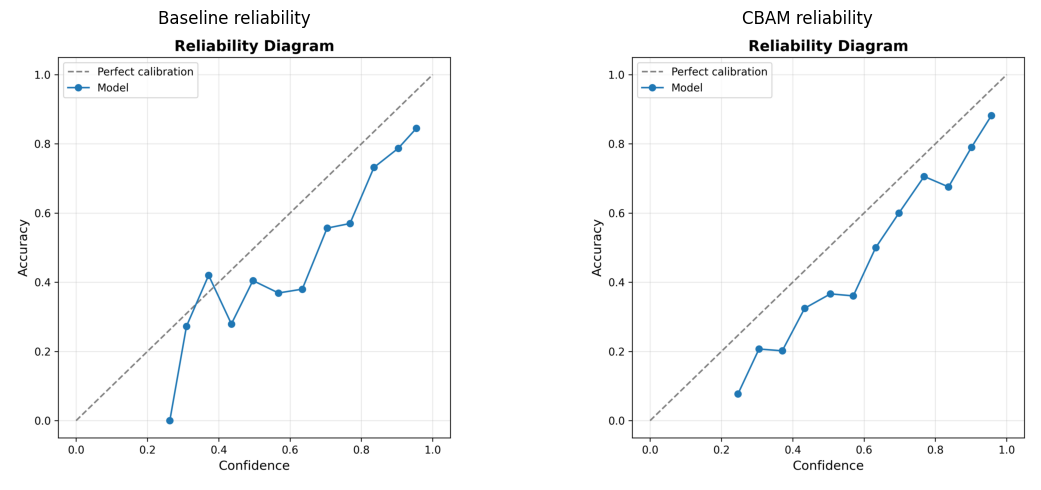

In [47]:
baseline_rel_path = latest_match(str(phase3_dir / "outputs" / "figures" / "baseline_messidor2_*_20T_1744img_reliability.png"))
cbam_rel_path = latest_match(str(phase3_dir / "outputs" / "figures" / "cbam_messidor2_*_20T_1744img_reliability.png"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, title in [
    (axes[0], baseline_rel_path, "Baseline reliability"),
    (axes[1], cbam_rel_path, "CBAM reliability"),
]:
    img = plt.imread(path)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

- Baseline > CBAM
- threshold/referral operating-point selection + temperature scaling
- cbam redesign